Checking how robust clusters are to perturbed inputs. For that we use remove-J jackknife robustness analysis. We remove 25% of the data each time, and see how much our clusters vary compared to our original cluster

- Load a matrix
- Do original clustering
- Subsample matrix multiple times
- Do clustering on subsample
- compare subsample to original

In [1]:
import pandas as pd
import copy
from pathlib import Path
from random import sample

import dill as pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score
from multiprocessing import Pool

In [2]:
atted_dist_path = Path('/home/noord087/lustre_link/phd/PycharmProjects/d3c2_project/data/raw_data/atted_ii/all_cor_one_matrix_renamed.parquet.gzip')
local_dist_path = Path('../data/preprocessed_data/gse65046/local_distance_matrix.pkl')
summed_dist_path = Path('atted_local_dist_summed_no_negative.parquet.gzip')

Start with local dists first

In [3]:
def from_dist_df_to_clustering(dist_df):        
    flat_dists = squareform(dist_df, checks=False)
    linkage_matrix = linkage(flat_dists, method='complete')
    og_clustering = fcluster(linkage_matrix, 500, 'maxclust')
    og_cluster_df = pd.DataFrame(og_clustering, index=dist_df.index, columns=['cluster_id'])
    return og_cluster_df

def random_subset_of_df(dist_df, size=0.75):
    rand_index = sample(dist_df.index.tolist(),
                        round(size*len(dist_df.index.tolist())))
    subset_df = dist_df.loc[rand_index,rand_index]
    return subset_df

def cluster_random_subset(dist_df):
    subset_df = random_subset_of_df(dist_df)
    cluster_df = from_dist_df_to_clustering(subset_df)
    return cluster_df

In [4]:
def compare_subset_cluster_to_og(subset_cluster_df, og_df):
    # Merge genes
    merged_df = subset_cluster_df.join(og_df, how='inner', lsuffix='_subset', rsuffix='_og')
    ari = adjusted_rand_score(merged_df['cluster_id_subset'],
                              merged_df['cluster_id_og'])
    return ari

In [5]:
def input_parser(in_path):
    if in_path.name.endswith('.pkl'):
        with open(in_path, 'rb') as f:
            in_dist_df = pickle.load(f)
    elif in_path.name.endswith('.parquet.gzip'):
        in_dist_df = pd.read_parquet(in_path)
        # Ensure columns are gene names as well
        if in_dist_df.index.dtype == 'int64':
            in_dist_df = in_dist_df.set_index(in_dist_df.columns[0])
            in_dist_df = in_dist_df.max().max() - in_dist_df
            # Make symmetrical
            in_dist_df = pd.DataFrame(squareform(squareform(in_dist_df, checks=False)), index=in_dist_df.index, columns=in_dist_df.columns)  
    else:
        raise NotImplementedError
    return in_dist_df

In [6]:
def wrapper(in_path, n_repeats=30, size=0.75, filter_list=None):
    in_dist_df = input_parser(in_path)
    
    print(len(in_dist_df))
    if filter_list:
        index = in_dist_df.index.isin(filter_list)
        in_dist_df = in_dist_df.loc[index, index]
    print(len(in_dist_df))
    
    og_df = from_dist_df_to_clustering(in_dist_df)

    # in_list = [random_subset_of_df(in_dist_df, size) for _ in range(n_repeats)]
    in_list = [in_dist_df for _ in range(n_repeats)]
    with Pool(n_repeats) as p:
        subset_cluster_df_list = p.map(cluster_random_subset, in_list)
    out_list = []
    for df in subset_cluster_df_list:
        ari_score = compare_subset_cluster_to_og(df, og_df)
        print(ari_score)
        out_list.append(ari_score)
    return out_list

        


In [7]:
filter_list = input_parser(summed_dist_path).index.tolist()

In [8]:
atted_scores = wrapper(atted_dist_path, filter_list=filter_list)

18957
18306
0.290661629888618
0.2862212914923944
0.29193753198297256
0.29025079866840253
0.3109125759654793
0.28392369416344776
0.27242495242707676
0.29755862024625795
0.30202924253570995
0.2777724794525411
0.3038825845007873
0.2862941509460782
0.30945544090906346
0.2831771680538963
0.29108872087032917
0.29893001584667783
0.29708571547667
0.2881634484041853
0.30633740626052114
0.2746547160609827
0.28505389046387986
0.30958688588078376
0.2893696194462897
0.2785519249943909
0.2767741245203566
0.2786788346210076
0.2744883058369375
0.2800009761182196
0.29880667847013426
0.28926237305439295


In [9]:
summed_scores = wrapper(summed_dist_path, filter_list=filter_list)

18306
18306
0.2267186829351419
0.2208964434994006
0.2260018646864607
0.21990375908234394
0.24045032982514994
0.2367553373330944
0.2217126441810986
0.2326640708132754
0.2315438888629246
0.22747183568891505
0.24745482154938028
0.22611101267854677
0.20808011359436834
0.2296127645253638
0.21421894407894676
0.2252747486553387
0.21959891210691346
0.21831430788199788
0.22879342170053837
0.22216128325956952
0.2221354484996038
0.2339259392373978
0.20412630938217968
0.23243402158161194
0.23323497028786552
0.21669635394024164
0.1983467769100342
0.22724068802013953
0.22794954987302393
0.23036209883678224


In [10]:
local_scores = wrapper(local_dist_path, filter_list=filter_list)

25074
18306
0.16861495584393113
0.14904410327201248
0.15822160727711107
0.16184976637900053
0.1719937674874703
0.15464337922449795
0.16019876205284284
0.1577994374654165
0.14939897933480276
0.16612266382974533
0.14624991056796194
0.1611520299989133
0.16559702993892084
0.16096023864619183
0.15343070131379236
0.14988508984919566
0.16169541625795175
0.14998199700707626
0.15715456187816482
0.1671930613968145
0.15230279159232135
0.15082933105248086
0.1620668812175404
0.15620227943563772
0.14540966019324625
0.15724883052355673
0.1597585419577104
0.1483176749850174
0.15299417459448506
0.15929962796318298


<Axes: xlabel='input_dists', ylabel='robustness'>

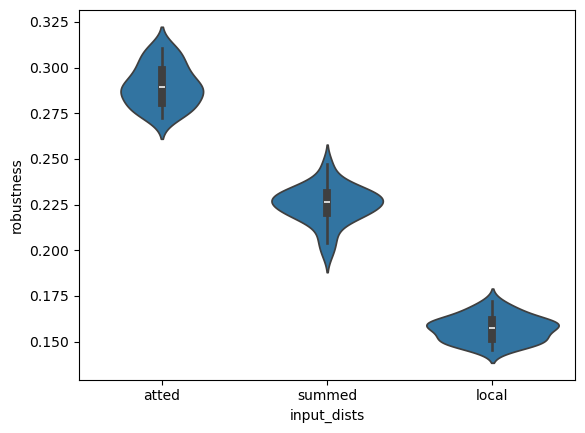

In [11]:
out_df = pd.DataFrame.from_dict({'atted': atted_scores, 'summed': summed_scores, 'local': local_scores})
out_df
out_df = out_df.melt(value_name='robustness', var_name='input_dists')
sns.violinplot(data=out_df, x='input_dists', y='robustness')

In [12]:
# Save to file for download
out_df.to_csv('robustness_30_jackknifes.csv')